In [36]:
import os, sys

from keras.models import Model, Sequential
from keras.layers import Input, LSTM, Dense, Embedding, Dropout, TimeDistributed, RepeatVector, SimpleRNN, Bidirectional, GRU
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from gensim.models import fasttext
from gensim.test.utils import datapath
from numpy import array, asarray, zeros
from nltk.translate.bleu_score import sentence_bleu
import pickle
import tensorflow as tf
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
BATCH_SIZE = 64
EPOCHS = 5
LSTM_NODES = 512
EMBEDDING_SIZE = 300
USE_SAVED = True

In [3]:
# function to load the dataset
def load_text_data_2(path, num_examples=20000):
    with open(path, 'r', encoding='utf-8') as file:
        text = file.read()

    sentences = text.strip().split('\n')  # Assuming '\p' is the intended delimiter
    print(path, ':', len(sentences))

    if num_examples:
        sentences = sentences[:num_examples]
    # Compile the regex pattern once for efficiency
    whitespace_pattern = re.compile(r'\s+')

    cleaned_sentences = []
    for sentence in sentences:
        cleaned_sentence = sentence.strip('\n').strip('\t').strip().replace('\n', ' ').replace('\t', ' ')
        cleaned_sentence = whitespace_pattern.sub(' ', cleaned_sentence)
        cleaned_sentences.append(cleaned_sentence.lower())

    return cleaned_sentences

In [4]:
# loading the datasetst
DATASETS_DIR = "/content/drive/My Drive/Great Learning Course/Main Project/"
# German
'''filepath =  DATASETS_DIR + 'commoncrawl_de_en.txt'
data_examples_commoncrawl = load_text_data_2(filepath)''' # corrupted
filepath = DATASETS_DIR + 'europarl-v7_de_en.txt'
data_examples_europarl = load_text_data_2(filepath)
'''filepath = DATASETS_DIR + 'news-commentary-v9_de_en.txt'
data_examples_news_commentary = load_text_data_2(filepath)''' # sentence break not defined properly
data_examples_ger = data_examples_europarl # + data_examples_news_commentary + data_examples_commoncrawl
print('German:', data_examples_ger[:5], '\n')

german_sentences = data_examples_ger # just ease of read
print("Number of samples in German:", len(german_sentences))

# English
'''filepath =  DATASETS_DIR + 'commoncrawl_en_de.txt'
data_examples_commoncrawl_eng = load_text_data_2(filepath)''' # corrupted
filepath = DATASETS_DIR + 'europarl-v7_en_de.txt'
data_examples_europarl_eng = load_text_data_2(filepath)
'''filepath = DATASETS_DIR + 'news-commentary-v9_en_de.txt'
data_examples_news_commentary_eng = load_text_data_2(filepath)''' # sentence break not defined properly
data_examples_eng = data_examples_europarl_eng # + data_examples_news_commentary_eng + data_examples_commoncrawl_eng
print('English:', data_examples_eng[:5], '\n')
english_sentences = [sentence + ' <eos>' for sentence in data_examples_eng] # for the beam search method to understand end of string (eos)
english_sentences_inputs = ['<sos> ' + sentence for sentence in data_examples_eng] # for the beam search method to understand start of string (sos)
print("Number of samples in English:", len(english_sentences))
print("Number of samples in English input:", len(english_sentences_inputs))

/content/drive/My Drive/Great Learning Course/Main Project/europarl-v7_de_en.txt : 1920209
German: ['wiederaufnahme der sitzungsperiode', 'ich erkläre die am freitag, dem 17. dezember unterbrochene sitzungsperiode des europäischen parlaments für wiederaufgenommen, wünsche ihnen nochmals alles gute zum jahreswechsel und hoffe, daß sie schöne ferien hatten.', 'wie sie feststellen konnten, ist der gefürchtete "millenium-bug " nicht eingetreten. doch sind bürger einiger unserer mitgliedstaaten opfer von schrecklichen naturkatastrophen geworden.', 'im parlament besteht der wunsch nach einer aussprache im verlauf dieser sitzungsperiode in den nächsten tagen.', 'heute möchte ich sie bitten - das ist auch der wunsch einiger kolleginnen und kollegen -, allen opfern der stürme, insbesondere in den verschiedenen ländern der europäischen union, in einer schweigeminute zu gedenken.'] 

Number of samples in German: 20000
/content/drive/My Drive/Great Learning Course/Main Project/europarl-v7_en_de.tx

We will are considering only one source file as first one as mentioned is corrupted and second does not map well with its counter parts. So, we now consider just one source with 20000 sentences.

In [5]:
# All second level data preprocessing functions
# We shall not go for some of these text preprocessing steps like stopwords, stemming as it might lose the context of the data
# Data Preprocessing
import nltk

def remove_punctuation(text):
    return re.sub(r'[^\w\s]','', text)

# stopword removal
def remove_stopwords(text, lang): # lang is for language as the library contains stopwords for both English and German
    stop_words = set(stopwords.words(lang))
    tokens = text.split(' ')
    filter_tokens = [word for word in tokens if word.lower() not in stop_words]
    return " ".join(filter_tokens)

# remove numeric
def remove_numeric(text):
    return re.sub(r'\d+','',text)

# Stemming
def apply_stemming(text):
    stemmer = PorterStemmer()
    tokens = text.split(' ')
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens)

def remove_mentions(text):
    return re.sub(r'@\w+','',text)

def remove_links(text):
    text = re.sub(r"www\S+", '', str(text), flags=re.MULTILINE)
    text = re.sub(r"http\S+", '', str(text), flags=re.MULTILINE)
    return text

# Lemmatization
def apply_lemmantizing(text):
    lemmatizer = WordNetLemmatizer()
    tokens = text.split(' ')
    lemma = [lemmatizer.lemmatize(word, 'v') for word in tokens]
    return " ".join(lemma)

# A complete helper function (currently only for English due to restrictions in Stemming and Lemmitization)
def text_preprocessing(sentence, lang):
    sentence = remove_links(sentence)
    sentence = remove_punctuation(sentence)
    sentence = remove_stopwords(sentence, lang)
    sentence = remove_numeric(sentence)
    sentence = apply_stemming(sentence)
    sentence = apply_lemmantizing(sentence)
    return sentence

In [6]:
#Cleaning
# These steps are done for exploratory purpose only
# German
print('German:')
example_german_sentence = german_sentences[52]
print(example_german_sentence)
stopwords_removed_sentence = remove_stopwords(example_german_sentence, 'german')
print('After Stopwords removal:', stopwords_removed_sentence)
'''full_cleaning = text_preprocessing(example_german_sentence)
print('After a full pre-processing:', full_cleaning)''' # as currently the stemmer and lemmatizer are only for English
# English
print('English:')
example_english_sentence = english_sentences[52]
print(example_english_sentence)
stopwords_removed_sentence = remove_stopwords(example_english_sentence, 'english')
print('After Stopwords removal:', stopwords_removed_sentence)
full_cleaning = text_preprocessing(example_english_sentence, 'english')
print('After a full pre-processing:', full_cleaning)

German:
die zuständigen dienste haben sie nicht in die tagesordnung aufgenommen, da sie der meinung waren, sie seien schon in einer vorangegangenen sitzung beantwortet worden.
After Stopwords removal: zuständigen dienste tagesordnung aufgenommen, meinung waren, seien schon vorangegangenen sitzung beantwortet worden.
English:
the competent services have not included them in the agenda on the grounds that they had been answered in a previous part-session. <eos>
After Stopwords removal: competent services included agenda grounds answered previous part-session. <eos>
After a full pre-processing: compet servic includ agenda grind answer previou part eo


In [7]:
word_counts = []
for sen in german_sentences:
    word_counts.append(len(sen.split(' ')))

average = sum(word_counts) / len(word_counts)
print('Average number of words in a German sentence: {}'.format(average))

word_counts = []
for sen in english_sentences:
    word_counts.append(len(sen.split(' ')))

average = sum(word_counts) / len(word_counts)
print('Average number of words in a English sentence: {}'.format(average - 1)) # -1 is for not counting <eos>

Average number of words in a German sentence: 23.44595
Average number of words in a English sentence: 25.51185


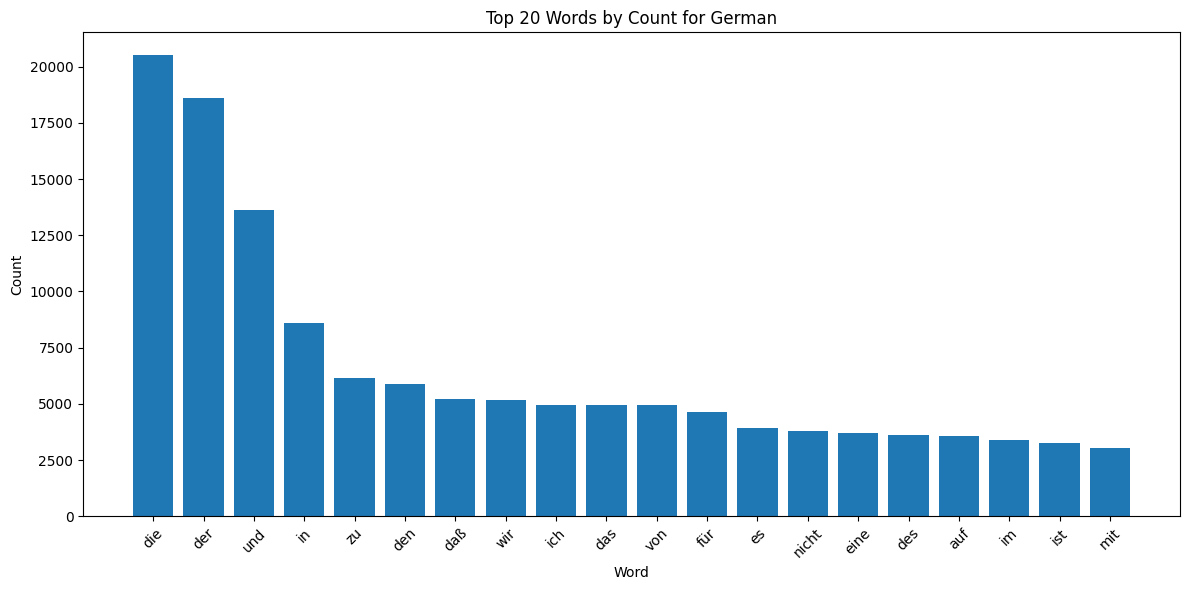

In [8]:
# Creating a bar plot to see the top 20 frequent German words
words_dict = {}
for sentence in german_sentences:
    for word in sentence.split(" "):
        if word in words_dict:
            words_dict[word] += 1
        else:
            words_dict[word] = 1

# sorting the word count dictionary in descending order
sorted_word_counts = dict(sorted(words_dict.items(), key=lambda item: item[1], reverse=True))

# Selecting the top 20 words
top_20_words = dict(list(sorted_word_counts.items())[:20])

# Extracting words and counts for plotting
words = list(top_20_words.keys())
counts = list(top_20_words.values())

# Creating a bar plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts)

# Set plot labels and title
plt.xlabel('Word')
plt.ylabel('Count')
plt.title('Top 20 Words by Count for German')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

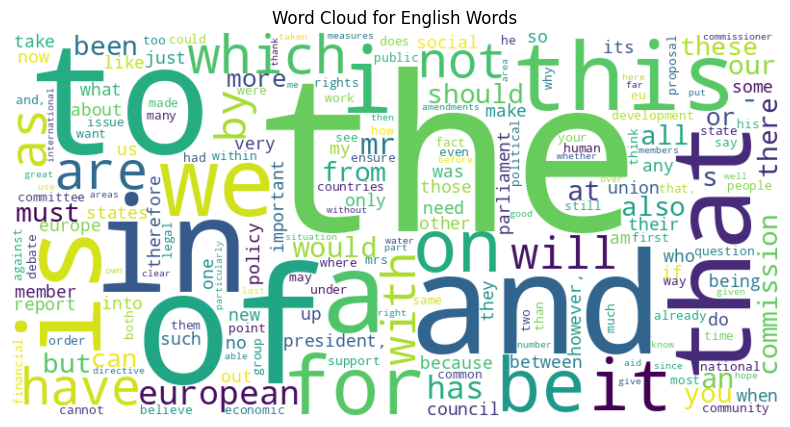

In [9]:
# Creating a WordCloud for most frequent English words
words_dict = {}
for sentence in english_sentences:
    for word in sentence.split(" "):
        if word in words_dict:
            words_dict[word] += 1
        else:
            words_dict[word] = 1

words_dict.pop('<eos>') # as this is only for beam search
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words_dict)

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for English Words')
plt.show()

As seen above, most of the common words are stopwords, but we keep them to maintain context as it is very important in transliteration as compared to normal translation. Also, we can see after the stopwords, some of the common words are 'international', 'social', 'state', which relays to us that the documentation is based on public affairs.

In [10]:
# German Tokenization
german_tokenizer = Tokenizer()
german_tokenizer.fit_on_texts(german_sentences)
german_integer_seq = german_tokenizer.texts_to_sequences(german_sentences)
german_word_index = german_tokenizer.word_index
len_german_word_index = len(german_word_index) + 1
print('Total unique words in German: %s' % len_german_word_index)

max_german_sentence_len = max(len(sen) for sen in german_integer_seq)
print("Length of longest sentence in German: %g" % max_german_sentence_len)

# Word Embedding for German
# As the Embedding sizes are big, we stored the matrix model using a .py file, and have directly uploaded the same here using pickle
# This helps in RAM optimisation of .ipynb files
german_embedding_pickle = DATASETS_DIR + 'german_embedded_matrix.pkl'
if os.path.exists(german_embedding_pickle) and USE_SAVED:
    with open(german_embedding_pickle, 'rb') as file:
        german_embedding_matrix = pickle.load(file)
        print('German matrix loaded')
else:
    # we have used FastText n-gram embedding for German which by default comes for 300 dimensions
    german_embedding_model_path = DATASETS_DIR + 'cc.de.300.bin'
    fasttext_model = fasttext.load_facebook_vectors(datapath(german_embedding_model_path))

    print('German matrix model loaded')

    german_embedding_matrix = np.zeros((len_german_word_index, EMBEDDING_SIZE))

    for word, i in german_word_index.items():
        if word in fasttext_model:
            german_embedding_matrix[i] = fasttext_model[word]

    with open(german_embedding_pickle, 'wb') as file:
        pickle.dump(german_embedding_matrix, file)
    print('German matrix created')

Total unique words in German: 29259
Length of longest sentence in German: 152
German matrix loaded


In [11]:
# English Tokenization
english_tokenizer = Tokenizer()
english_tokenizer.fit_on_texts(english_sentences + english_sentences_inputs)
english_integer_seq = english_tokenizer.texts_to_sequences(english_sentences)
english_input_integer_seq = english_tokenizer.texts_to_sequences(english_sentences_inputs)

english_word_index = english_tokenizer.word_index
len_english_word_index = len(english_word_index) + 1
print('Total unique words in English: %s' % len_english_word_index)

max_english_sentence_len = max(len(sen) for sen in english_integer_seq)
print("Length of longest sentence in English: %g" % max_english_sentence_len)

english_embedding_pickle = DATASETS_DIR + 'english_embedded_matrix.pkl'
if os.path.exists(english_embedding_pickle) and USE_SAVED:
    with open(english_embedding_pickle, 'rb') as file:
        english_embedding_matrix = pickle.load(file)
        print('English matrix loaded')
else:
    english_embeddings_dictionary = dict()
    # here we used the standard glove library for vectorization, and as German uses 300 dimensions have used same for English as well
    glove_path = DATASETS_DIR + 'glove.6B.300d.txt'
    glove_file = open(glove_path, encoding="utf8")

    for line in glove_file:
        records = line.split()
        word = records[0]
        vector_dimensions = asarray(records[1:], dtype='float32')
        english_embeddings_dictionary[word] = vector_dimensions
    glove_file.close()

    print('English matrix model loaded')

    english_embedding_matrix = zeros((len_english_word_index, EMBEDDING_SIZE))
    for word, index in english_word_index.items():
        embedding_vector = english_embeddings_dictionary.get(word)
        if embedding_vector is not None:
            english_embedding_matrix[index] = embedding_vector

    with open(english_embedding_pickle, 'wb') as file:
        pickle.dump(english_embedding_matrix, file)
    print('English matrix created')

Total unique words in English: 15186
Length of longest sentence in English: 162
English matrix loaded


In [12]:
# adding padding for uniformity
# German
encoder_german_sequences = pad_sequences(german_integer_seq, maxlen=max_german_sentence_len)
print("encoder_input_sequences.shape:", encoder_german_sequences.shape)
print("encoder_input_sequences[172]:", encoder_german_sequences[172])
# English
decoder_english_sequences = pad_sequences(english_input_integer_seq, maxlen=max_english_sentence_len, padding='post')
print("decoder_input_sequences.shape:", decoder_english_sequences.shape)
print("decoder_input_sequences[172]:", decoder_english_sequences[172])

encoder_input_sequences.shape: (20000, 152)
encoder_input_sequences[172]: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0   13    6   50 2652 2343  285   18  310   13  835    3
 1078    2    1 7179  320    2  134  185  487   10   32  772]
decoder_input_sequences.shape: (20000, 162)
decoder_input_sequences[172]: [   7    1   56 2229  325  266    2    1  100   16  246   63    4  424
   18  35

For German zeros are added at the beginning as encoder output would be based on the words occuring at the end of the sentence, thus original sentence is at the end. <br>
While for English post padding is added, as the encoder processing would be starting from the beginning of the sentence.

In [13]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_Y, test_Y = train_test_split(encoder_german_sequences, decoder_english_sequences, test_size=0.2, random_state= 12)

Altough we have done train, test split, we haven't been able to use it. As, we wanted to test the model on training data itself even though if it would have resulted in over fitting. We wanted to check if the model was actually capable of perdicting known knowledge first.

Defining **Simple LSTM** model with embeddings, encoders and decoders

In [14]:
# Encoder
simple_lstm_encoder_inputs = Input(shape=(max_german_sentence_len,))
simple_lstm_encoder_embedding_layer = Embedding(len_german_word_index, EMBEDDING_SIZE, weights=[german_embedding_matrix], input_length=max_german_sentence_len)
career_encoder = simple_lstm_encoder_embedding_layer(simple_lstm_encoder_inputs)
simple_lstm_encoder = LSTM(LSTM_NODES, return_state=True)
simple_lstm_encoder_outputs, simple_lstm_h, simple_lstm_c = simple_lstm_encoder(career_encoder)
simple_lstm_encoder_states = [simple_lstm_h, simple_lstm_c]

# Decoder
simple_lstm_decoder_inputs = Input(shape=(max_english_sentence_len,))
simple_lstm_decoder_embedding_layer = Embedding(len_english_word_index, EMBEDDING_SIZE, weights=[english_embedding_matrix], input_length=max_english_sentence_len)
career_decoder = simple_lstm_decoder_embedding_layer(simple_lstm_decoder_inputs)
simple_lstm_decoder = LSTM(LSTM_NODES, return_sequences=True, return_state=True)
simple_lstm_decoder_outputs, _, _ = simple_lstm_decoder(career_decoder, initial_state=simple_lstm_encoder_states)

simple_lstm_decoder_dense = Dense(len_english_word_index, activation='softmax')
simple_lstm_decoder_outputs = simple_lstm_decoder_dense(simple_lstm_decoder_outputs)

# Final Model
simple_lstm_model = Model([simple_lstm_encoder_inputs, simple_lstm_decoder_inputs], simple_lstm_decoder_outputs)
simple_lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
simple_lstm_model.fit([encoder_german_sequences, decoder_english_sequences],
    decoder_english_sequences,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1
)

Epoch 1/5
282/282 [==============================] - 64s 190ms/step - loss: 1.1153 - accuracy: 0.8789 - val_loss: 0.5329 - val_accuracy: 0.9367
Epoch 2/5
282/282 [==============================] - 28s 99ms/step - loss: 0.2891 - accuracy: 0.9668 - val_loss: 0.1966 - val_accuracy: 0.9799
Epoch 3/5
282/282 [==============================] - 20s 71ms/step - loss: 0.1074 - accuracy: 0.9887 - val_loss: 0.1083 - val_accuracy: 0.9896
Epoch 4/5
282/282 [==============================] - 18s 63ms/step - loss: 0.0541 - accuracy: 0.9943 - val_loss: 0.0770 - val_accuracy: 0.9930
Epoch 5/5
282/282 [==============================] - 17s 61ms/step - loss: 0.0316 - accuracy: 0.9966 - val_loss: 0.0625 - val_accuracy: 0.9945


In [18]:
# Building different encoder and decoder models for Beam search method for prediction
simple_lstm_encoder_model = Model(simple_lstm_encoder_inputs, simple_lstm_encoder_states)
simple_lstm_decoder_state_input_h = Input(shape=(LSTM_NODES,))
simple_lstm_decoder_state_input_c = Input(shape=(LSTM_NODES,))
simple_lstm_decoder_states_inputs = [simple_lstm_decoder_state_input_h, simple_lstm_decoder_state_input_c]
simple_lstm_decoder_inputs_single = Input(shape=(1,))
simple_lstm_decoder_inputs_single_career = simple_lstm_decoder_embedding_layer(simple_lstm_decoder_inputs_single)
simple_lstm_decoder_model_outputs, simple_lstm_decoder_h, simple_lstm_decoder_c = simple_lstm_decoder(simple_lstm_decoder_inputs_single_career, initial_state=simple_lstm_decoder_states_inputs)
simple_lstm_decoder_states = [simple_lstm_decoder_h, simple_lstm_decoder_c]
simple_lstm_decoder_model_outputs = simple_lstm_decoder_dense(simple_lstm_decoder_model_outputs)
simple_lstm_decoder_model = Model(
    [simple_lstm_decoder_inputs_single] + simple_lstm_decoder_states_inputs,
    [simple_lstm_decoder_model_outputs] + simple_lstm_decoder_states
)

english_word_index_target = {v:k for k, v in english_word_index.items()}

def translate_sentence(input_seq):
    states_value = simple_lstm_encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = english_word_index.get('<sos>')
    eos = english_word_index.get('<eos>')
    output_sentence = []

    for _ in range(max_english_sentence_len):
        output_tokens, h, c = simple_lstm_decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        if eos == idx:
            break

        word = ''

        if idx > 0:
            word = english_word_index_target[idx]
            output_sentence.append(word)

        target_seq[0, 0] = idx
        states_value = [h, c]

    return ' '.join(output_sentence)

In [19]:
i = np.random.choice(len(german_sentences))
german_sequence = encoder_german_sequences[i:i+1]
translation = translate_sentence(german_sequence)
print('Input:', german_sentences[i])
print('Output:', english_sentences[i])
print('Translation:', translation)

Input: die anfrage besteht aus mehreren teilen.
Output: this question covers several individual matters. <eos>
Translation: 


In [20]:
# Deploying BLEU Scoring for better accuracy testing of the model in case of translations
# Create lists to store reference and translated sentences
reference_sentences = []
translated_sentences = []

for i in range(10):
    german_sequence = encoder_german_sequences[i:i + 1]
    translation = translate_sentence(german_sequence)

    reference_sentences.append(english_sentences[i])
    translated_sentences.append(translation)
    print('Record prediction done for the sequence number:', str(i + 1))

# New we calculate BLEU scores for each pair of reference and translated sentences
bleu_scores = []

for reference, translation in zip(reference_sentences, translated_sentences):
    reference = reference.split()
    translation = translation.split()
    score = sentence_bleu([reference], translation)
    print('Score:', score)
    bleu_scores.append(score)

# Calculating the average BLEU score for the 10 sequences
len_bleu_scores = len(bleu_scores)
print('Total Scores:', len_bleu_scores)
if len_bleu_scores == 0:
    average_bleu_score = 0
else:
    average_bleu_score = sum(bleu_scores) / len_bleu_scores

print("Average BLEU Score:", average_bleu_score)

Record predicted for the score: 1
Record predicted for the score: 2
Record predicted for the score: 3
Record predicted for the score: 4
Record predicted for the score: 5
Record predicted for the score: 6
Record predicted for the score: 7
Record predicted for the score: 8
Record predicted for the score: 9
Record predicted for the score: 10
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Total Scores: 10
Average BLEU Score: 0.0


Defining **Simple RNN** model with embeddings, encoders and decoders

In [32]:
model_rnn = Sequential()
# Embedding Layer
model_rnn.add(Embedding(len_german_word_index,
                        EMBEDDING_SIZE, weights=[german_embedding_matrix],
                        input_length=max_german_sentence_len, mask_zero=True))
# Encoder
model_rnn.add(SimpleRNN(LSTM_NODES))
model_rnn.add(RepeatVector(max_english_sentence_len))
# Decoder
model_rnn.add(SimpleRNN(LSTM_NODES, return_sequences=True))
model_rnn.add(TimeDistributed(Dense(32, activation='relu')))
model_rnn.add(Dropout(0.5))
model_rnn.add(TimeDistributed(Dense(len_english_word_index, activation='softmax')))

# Final Model
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [33]:
from keras.callbacks import ModelCheckpoint
filename= 'model-1.h2.txt'
checkpoint= ModelCheckpoint(filename, monitor='Val_loss, Val_accuracy', Verbose=1, save_best_only=True, mode=min)
history = model_rnn.fit(encoder_german_sequences, decoder_english_sequences,
              epochs= 5, batch_size=64, validation_split= 0.2,
              callbacks=[checkpoint], verbose=1)

Epoch 1/5
250/250 [==============================] - ETA: 0s - loss: 2.3211 - accuracy: 0.8116

250/250 [==============================] - 81s 308ms/step - loss: 2.3211 - accuracy: 0.8116 - val_loss: 1.8871 - val_accuracy: 0.8364
Epoch 2/5
250/250 [==============================] - ETA: 0s - loss: 2.0040 - accuracy: 0.8341

250/250 [==============================] - 63s 252ms/step - loss: 2.0040 - accuracy: 0.8341 - val_loss: 1.5502 - val_accuracy: 0.8424
Epoch 3/5
250/250 [==============================] - ETA: 0s - loss: 1.6564 - accuracy: 0.8400

250/250 [==============================] - 62s 247ms/step - loss: 1.6564 - accuracy: 0.8400 - val_loss: 1.5382 - val_accuracy: 0.8423
Epoch 4/5
250/250 [==============================] - ETA: 0s - loss: 1.6484 - accuracy: 0.8411

250/250 [==============================] - 62s 249ms/step - loss: 1.6484 - accuracy: 0.8411 - val_loss: 1.5527 - val_accuracy: 0.8423
Epoch 5/5
250/250 [==============================] - ETA: 0s - loss: 1.6455 - accuracy: 0.8412

250/250 [==============================] - 60s 239ms/step - loss: 1.6455 - accuracy: 0.8412 - val_loss: 1.5431 - val_accuracy: 0.8422


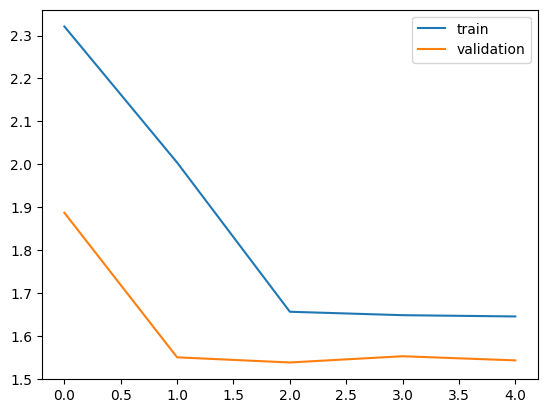

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'])
plt.show()

We can see that the model learning came to an hault for the above design. We tried with batch_size = 16 and epochs 3 where it was close to reaching an accuracy of 84%. But in the current state it stays there. <br>
Also in other models design the accuracy went down instead of going up, so staying with this as the final model.

In [35]:
print("Test German sentence")
print(german_sentences[41])
print("Original Translation")
print(english_sentences[41])
print("Predicted Translation")
prediction = model_rnn.predict(encoder_german_sequences[41: 41 + 1])
prediction_text = german_tokenizer.sequences_to_texts(prediction[:, 0])
print(prediction_text)

Test German sentence
frau präsidentin, können sie mir sagen, warum sich dieses parlament nicht an die arbeitsschutzregelungen hält, die es selbst verabschiedet hat?
Original Translation
madam president, can you tell me why this parliament does not adhere to the health and safety legislation that it actually passes? <eos>
Predicted Translation
1/1 [==============================] - 0s 304ms/step
['']


As we can see, even this model fails to predict anything and so we don't see a point in running the BLUE Scoring.

Defining **Bidirectional LSTM** model with embeddings, encoders and decoders

In [43]:
bi_lstm_encoder_inputs = Input(shape=(max_german_sentence_len,))
bi_lstm_encoder_embedding_layer = Embedding(len_german_word_index, EMBEDDING_SIZE, weights=[german_embedding_matrix], input_length=max_german_sentence_len)
bi_career_encoder = bi_lstm_encoder_embedding_layer(bi_lstm_encoder_inputs)
bi_lstm_encoder = Bidirectional(LSTM(LSTM_NODES, return_state=True))
# Adding a Bidirectional Layer after the LSTM layer
bi_lstm_encoder_outputs, bi_forward_h, bi_forward_c, bi_backward_h, bi_backward_c = bi_lstm_encoder(bi_career_encoder)
bi_lstm_encoder_states = [bi_forward_h, bi_forward_c, bi_backward_h, bi_backward_c]

# Decoder
bi_lstm_decoder_inputs = Input(shape=(max_english_sentence_len,))
bi_lstm_decoder_embedding_layer = Embedding(len_english_word_index, EMBEDDING_SIZE, weights=[english_embedding_matrix], input_length=max_english_sentence_len)
bi_career_decoder = bi_lstm_decoder_embedding_layer(bi_lstm_decoder_inputs)
bi_lstm_decoder = Bidirectional(LSTM(LSTM_NODES, return_sequences=True, return_state=True))
# Adding a Bidirectional Layer after the LSTM layer
bi_lstm_decoder_outputs, _, _, _, _ = bi_lstm_decoder(bi_career_decoder, initial_state=bi_lstm_encoder_states)

bi_lstm_decoder_dense = Dense(len_english_word_index, activation='softmax')
bi_lstm_decoder_outputs = bi_lstm_decoder_dense(bi_lstm_decoder_outputs)

# Final Model
bi_lstm_model = Model([bi_lstm_encoder_inputs, bi_lstm_decoder_inputs], bi_lstm_decoder_outputs)
bi_lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [44]:
bi_lstm_model.fit([encoder_german_sequences, decoder_english_sequences],
    decoder_english_sequences,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1
)

Epoch 1/5
282/282 [==============================] - 55s 175ms/step - loss: 0.8319 - accuracy: 0.9156 - val_loss: 0.2767 - val_accuracy: 0.9698
Epoch 2/5
282/282 [==============================] - 32s 113ms/step - loss: 0.1202 - accuracy: 0.9873 - val_loss: 0.0988 - val_accuracy: 0.9905
Epoch 3/5
282/282 [==============================] - 27s 97ms/step - loss: 0.0432 - accuracy: 0.9952 - val_loss: 0.0665 - val_accuracy: 0.9941
Epoch 4/5
282/282 [==============================] - 25s 88ms/step - loss: 0.0207 - accuracy: 0.9974 - val_loss: 0.0551 - val_accuracy: 0.9954
Epoch 5/5
282/282 [==============================] - 23s 82ms/step - loss: 0.0103 - accuracy: 0.9987 - val_loss: 0.0500 - val_accuracy: 0.9964


Using Bidirectional layers took us to a higher accuracy pretty quickly, but the final accuracy was just marginally more.

In [47]:
# Building different encoder and decoder models for Beam search method for prediction
bi_lstm_encoder_model = Model(bi_lstm_encoder_inputs, bi_lstm_encoder_states)
bi_lstm_decoder_state_input_forward_h = Input(shape=(LSTM_NODES,))
bi_lstm_decoder_state_input_forward_c = Input(shape=(LSTM_NODES,))
bi_lstm_decoder_state_input_backward_h = Input(shape=(LSTM_NODES,))
bi_lstm_decoder_state_input_backward_c = Input(shape=(LSTM_NODES,))
bi_lstm_decoder_states_inputs = [bi_lstm_decoder_state_input_forward_h, bi_lstm_decoder_state_input_forward_c,
                                 bi_lstm_decoder_state_input_backward_h, bi_lstm_decoder_state_input_backward_c]
bi_lstm_decoder_inputs_single = Input(shape=(1,))
bi_lstm_decoder_inputs_single_career = bi_lstm_decoder_embedding_layer(bi_lstm_decoder_inputs_single)
bi_lstm_decoder_model_outputs, bi_lstm_decoder_forward_h, bi_lstm_decoder_forward_c, bi_lstm_decoder_backward_h, bi_lstm_decoder_backward_c = bi_lstm_decoder(bi_lstm_decoder_inputs_single_career, initial_state=bi_lstm_decoder_states_inputs)
bi_lstm_decoder_states = [bi_lstm_decoder_forward_h, bi_lstm_decoder_forward_c, bi_lstm_decoder_backward_h, bi_lstm_decoder_backward_c]
bi_lstm_decoder_model_outputs = bi_lstm_decoder_dense(bi_lstm_decoder_model_outputs)
bi_lstm_decoder_model = Model(
    [bi_lstm_decoder_inputs_single] + bi_lstm_decoder_states_inputs,
    [bi_lstm_decoder_model_outputs] + bi_lstm_decoder_states
)

english_word_index_target = {v:k for k, v in english_word_index.items()}

def translate_sentence_bidirectional(input_seq):
    states_value = bi_lstm_encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = english_word_index.get('<sos>')
    eos = english_word_index.get('<eos>')
    output_sentence = []

    for _ in range(max_english_sentence_len):
        output_tokens, forward_h, forward_c, backward_h, backward_c = bi_lstm_decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        if eos == idx:
            break

        word = ''

        if idx > 0:
            word = english_word_index_target[idx]
            output_sentence.append(word)

        target_seq[0, 0] = idx
        states_value = [forward_h, forward_c, backward_h, backward_c]

    return ' '.join(output_sentence)

In [48]:
i = np.random.choice(len(german_sentences))
german_sequence = encoder_german_sequences[i:i+1]
translation = translate_sentence_bidirectional(german_sequence)
print('Input:', german_sentences[i])
print('Output:', english_sentences[i])
print('Translation:', translation)

Input: schiffbruch der erika
Output: shipwreck of the erika <eos>
Translation: 


In [49]:
# Deploying BLEU Scoring for better accuracy testing of the model in case of translations
# Create lists to store reference and translated sentences
reference_sentences = []
translated_sentences = []

for i in range(10):
    german_sequence = encoder_german_sequences[i:i + 1]
    translation = translate_sentence_bidirectional(german_sequence)

    reference_sentences.append(english_sentences[i])
    translated_sentences.append(translation)
    print('Record prediction done for the sequence number:', str(i + 1))

# New we calculate BLEU scores for each pair of reference and translated sentences
bleu_scores = []

for reference, translation in zip(reference_sentences, translated_sentences):
    reference = reference.split()
    translation = translation.split()
    score = sentence_bleu([reference], translation)
    print('Score:', score)
    bleu_scores.append(score)

# Calculating the average BLEU score for the 10 sequences
len_bleu_scores = len(bleu_scores)
print('Total Scores:', len_bleu_scores)
if len_bleu_scores == 0:
    average_bleu_score = 0
else:
    average_bleu_score = sum(bleu_scores) / len_bleu_scores

print("Average BLEU Score:", average_bleu_score)

Record prediction done for the sequence number: 1
Record prediction done for the sequence number: 2
Record prediction done for the sequence number: 3
Record prediction done for the sequence number: 4
Record prediction done for the sequence number: 5
Record prediction done for the sequence number: 6
Record prediction done for the sequence number: 7
Record prediction done for the sequence number: 8
Record prediction done for the sequence number: 9
Record prediction done for the sequence number: 10
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Score: 0
Total Scores: 10
Average BLEU Score: 0.0


We still couldn't get a prediction

Defining **Bidirectional RNN** model with embeddings, encoders and decoders

In [50]:
model_rnn = Sequential()
# Embedding Layer
model_rnn.add(Embedding(len_german_word_index,
                        EMBEDDING_SIZE, weights=[german_embedding_matrix],
                        input_length=max_german_sentence_len, mask_zero=True))
# Encoder
model_rnn.add(Bidirectional(SimpleRNN(LSTM_NODES)))
model_rnn.add(RepeatVector(max_english_sentence_len))
# Decoder
model_rnn.add(Bidirectional(SimpleRNN(LSTM_NODES, return_sequences=True)))
model_rnn.add(TimeDistributed(Dense(32, activation='relu')))
model_rnn.add(Dropout(0.5))
model_rnn.add(TimeDistributed(Dense(len_english_word_index, activation='softmax')))

# Final Model
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [51]:
filename= 'model-2.h2.txt'
checkpoint= ModelCheckpoint(filename, monitor='Val_loss, Val_accuracy', Verbose=1, save_best_only=True, mode=min)
history = model_rnn.fit(encoder_german_sequences, decoder_english_sequences,
              epochs= 5, batch_size=64, validation_split= 0.2,
              callbacks=[checkpoint], verbose=1)

Epoch 1/5
250/250 [==============================] - ETA: 0s - loss: 2.0990 - accuracy: 0.8242

250/250 [==============================] - 123s 470ms/step - loss: 2.0990 - accuracy: 0.8242 - val_loss: 1.6382 - val_accuracy: 0.8362
Epoch 2/5
250/250 [==============================] - ETA: 0s - loss: 1.7568 - accuracy: 0.8352

250/250 [==============================] - 100s 401ms/step - loss: 1.7568 - accuracy: 0.8352 - val_loss: 1.6286 - val_accuracy: 0.8364
Epoch 3/5
250/250 [==============================] - ETA: 0s - loss: 1.7382 - accuracy: 0.8361

250/250 [==============================] - 97s 387ms/step - loss: 1.7382 - accuracy: 0.8361 - val_loss: 1.6090 - val_accuracy: 0.8364
Epoch 4/5
250/250 [==============================] - ETA: 0s - loss: 1.7484 - accuracy: 0.8362

250/250 [==============================] - 97s 387ms/step - loss: 1.7484 - accuracy: 0.8362 - val_loss: 1.5883 - val_accuracy: 0.8376
Epoch 5/5
250/250 [==============================] - ETA: 0s - loss: 1.7243 - accuracy: 0.8370

250/250 [==============================] - 96s 383ms/step - loss: 1.7243 - accuracy: 0.8370 - val_loss: 1.5840 - val_accuracy: 0.8394


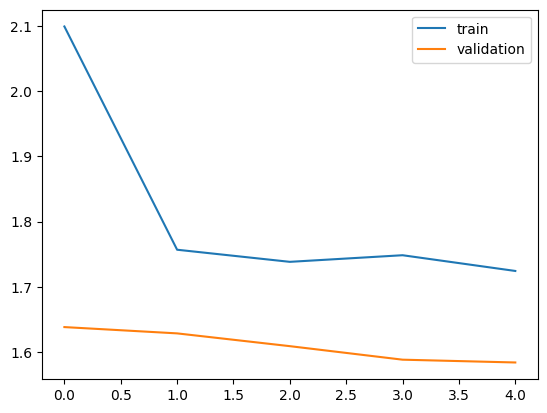

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'validation'])
plt.show()

In [53]:
print("Test German sentence")
print(german_sentences[41])
print("Original Translation")
print(english_sentences[41])
print("Predicted Translation")
prediction = model_rnn.predict(encoder_german_sequences[41: 41 + 1])
prediction_text = german_tokenizer.sequences_to_texts(prediction[:, 0])
print(prediction_text)

Test German sentence
frau präsidentin, können sie mir sagen, warum sich dieses parlament nicht an die arbeitsschutzregelungen hält, die es selbst verabschiedet hat?
Original Translation
madam president, can you tell me why this parliament does not adhere to the health and safety legislation that it actually passes? <eos>
Predicted Translation
1/1 [==============================] - 1s 534ms/step
['']


We get worser accuracies here. And as usual no translations.

Out of the four trained models, Bidirectional LSTM looks promising and worth further investigating. Thus, we'll store the same using pickle.

In [54]:
german_to_english_model_pickle = DATASETS_DIR + 'german_to_english_model.pkl'
with open(german_to_english_model_pickle, 'wb') as file:
    pickle.dump(bi_lstm_model, file)
    print('Model Saved!')

Model Saved!


In [55]:
# as the above model requires encoder and decoder model as well for predictions, we store them as well
german_to_english_encoder_model_pickle = DATASETS_DIR + 'german_to_english_encoder_model.pkl'
with open(german_to_english_encoder_model_pickle, 'wb') as file:
    pickle.dump(bi_lstm_encoder_model, file)
    print('Encoder Model Saved!')

german_to_english_decoder_model_pickle = DATASETS_DIR + 'german_to_english_decoder_model.pkl'
with open(german_to_english_decoder_model_pickle, 'wb') as file:
    pickle.dump(bi_lstm_decoder_model, file)
    print('Decoder Model Saved!')


Encoder Model Saved!
Decoder Model Saved!


1. The predictions are still not obtained. We need more hardware and more data to train on probably. <br>
2. We might try stemming/lemmitization for outputs but they might not work in transliteration. <br>
3. One of the approaches we came accross was using one hot encoding, but we could not implement due to memory issue. For the same model configuration it wanted to reserve more than 66 GB of memory. <br>
4. We also tried weighted classification during embedding, as seen in the interim submission, but vector embeddings were better in terms of accuracy. <br>
5. We can also further try methods like transfer learning, and Grid Search for hyper paratmeter tuning.